In [116]:
import os
import json
import cv2
import numpy as np

DATA_PATH = "Data/Hurricane"
IMG_SIZE = 224

X_cnn = []
y_cnn = []

for json_file in os.listdir(f"{DATA_PATH}/JSON"):
    
    with open(f"{DATA_PATH}/JSON/{json_file}") as f:
        data = json.load(f)

    frame_path = os.path.join(DATA_PATH, data["Frame_Name"])
    image = cv2.imread(frame_path)

    if image is None:
        print("Could not read image:", frame_path)
        continue

    # OpenCV loads as BGR, convert to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    for building in data["Buildings"]:
        
        mask_filename = building[2]
        label = building[3]

        mask_path = os.path.join(DATA_PATH, "MASK", mask_filename)

        if not os.path.exists(mask_path):
            continue

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if mask is None:
            print("Could not read mask:", mask_path)
            continue

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = mask / 255.0
        mask = np.expand_dims(mask, axis=-1)

        # Combine RGB image + mask channel
        combined = np.concatenate([image, mask], axis=-1)

        X_cnn.append(combined)
        y_cnn.append(label)

X_cnn = np.array(X_cnn, dtype=np.float32)
y_cnn = np.array(y_cnn, dtype=np.int64)

print("X_cnn shape:", X_cnn.shape)
print("y_cnn shape:", y_cnn.shape)
print("Labels:", sorted(set(y_cnn)))

X_cnn shape: (1458, 224, 224, 4)
y_cnn shape: (1458,)
Labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [117]:
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

print("X_train_cnn:", X_train_cnn.shape)
print("X_test_cnn:", X_test_cnn.shape)
print("y_train_cnn:", y_train_cnn.shape)
print("y_test_cnn:", y_test_cnn.shape)

X_train_cnn: (1166, 224, 224, 4)
X_test_cnn: (292, 224, 224, 4)
y_train_cnn: (1166,)
y_test_cnn: (292,)


In [118]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_cnn)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_cnn
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_array)
}

print(class_weights)

{0: 1.4502487562189055, 1: 0.9210110584518167, 2: 1.237791932059448, 3: 0.5238095238095238, 4: 0.9433656957928802, 5: 2.2337164750957856}


In [119]:
import tensorflow as tf
from tensorflow.keras import layers, models

num_classes = len(np.unique(y_cnn))

cnn = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_80 (Conv2D)              │ (None, 222, 222, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_78 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993,638 (19.05 MB)

 Trainable params: 4,993,638 (19.05 MB)

 Non-trainable params: 0 (0.00 B)

In [120]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

X_train_cnn, X_val_cnn, y_train_cnn, y_val_cnn = train_test_split(
    X_train_cnn,
    y_train_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_train_cnn
)

history = cnn.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=30,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 144ms/step - accuracy: 0.1695 - loss: 1.7964 - val_accuracy: 0.1795 - val_loss: 1.7906
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 143ms/step - accuracy: 0.1652 - loss: 1.7871 - val_accuracy: 0.2991 - val_loss: 1.7111
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 141ms/step - accuracy: 0.2629 - loss: 1.7609 - val_accuracy: 0.2863 - val_loss: 1.7006
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - accuracy: 0.3197 - loss: 1.7016 - val_accuracy: 0.3462 - val_loss: 1.6609
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - accuracy: 0.3530 - loss: 1.6036 - val_accuracy: 0.3803 - val_loss: 1.6339
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.4303 - loss: 1.4268 - val_accuracy: 0.3675 - val_loss: 1.6167
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.4828 - loss: 1.3123 - val_accuracy: 0.3889 - val_loss: 1.6040
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.5612 - loss: 1.1722 - val_accuracy: 0.

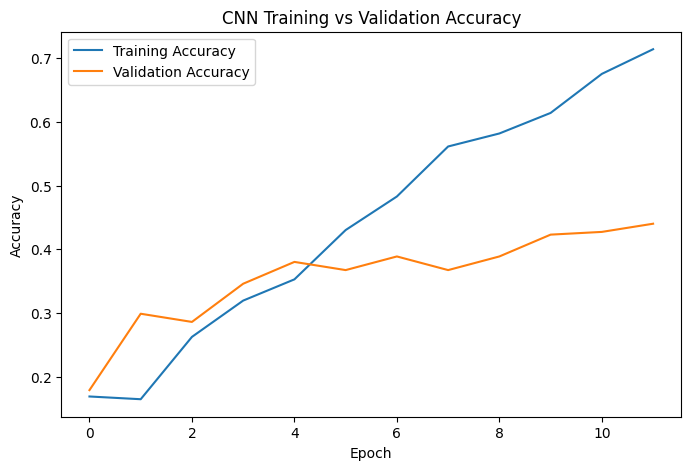

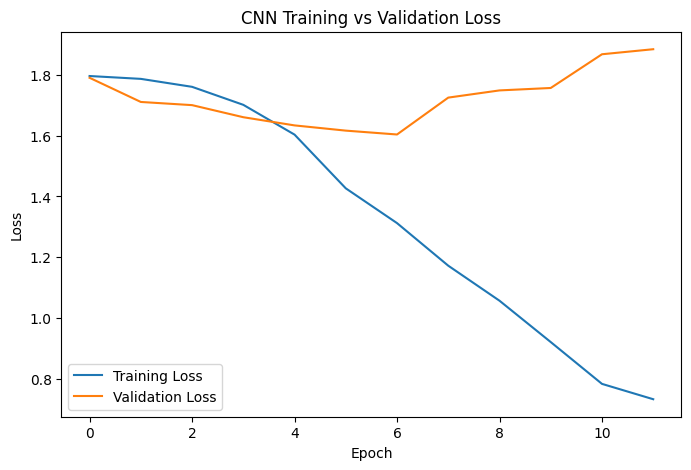

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training vs Validation Loss")
plt.legend()
plt.show()

In [122]:
test_loss, test_acc = cnn.evaluate(X_test_cnn, y_test_cnn, verbose=0)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_acc)

CNN Test Loss: 1.4825266599655151
CNN Test Accuracy: 0.4383561611175537


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
              precision    recall  f1-score   support

           0       0.26      0.32      0.29        34
           1       0.47      0.49      0.48        53
           2       0.43      0.41      0.42        39
           3       0.55      0.55      0.55        93
           4       0.44      0.29      0.35        52
           5       0.30      0.43      0.35        21

    accuracy                           0.44       292
   macro avg       0.41      0.41      0.41       292
weighted avg       0.45      0.44      0.44       292



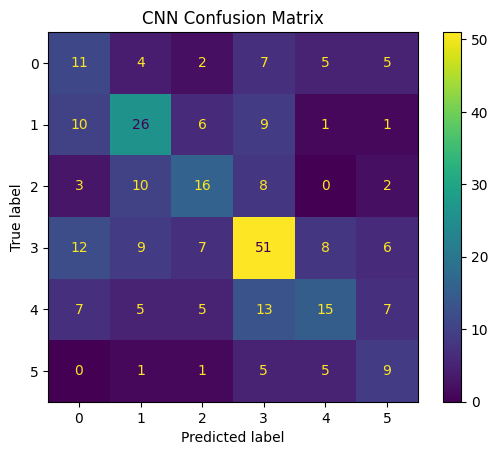

In [123]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

y_pred_probs = cnn.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test_cnn, y_pred_cnn))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_cnn)
plt.title("CNN Confusion Matrix")
plt.show()

In [124]:
def within_one_accuracy(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs(y_true - y_pred) <= 1)

cnn_pm1_acc = within_one_accuracy(y_test_cnn, y_pred_cnn)

print("CNN Strict Accuracy:", test_acc)
print("CNN ±1 Class Accuracy:", cnn_pm1_acc)

CNN Strict Accuracy: 0.4383561611175537
CNN ±1 Class Accuracy: 0.7054794520547946


In [125]:
import pandas as pd

cnn_results = pd.DataFrame([
    {
        "Model": "CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    }
])

cnn_results

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,CNN,0.438356,0.705479,1.482527


In [126]:

num_classes = len(np.unique(y_cnn))

cnn_small = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    # Data augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

cnn_small.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_small.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_15 (RandomFlip)     │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_15              │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_15 (RandomZoom)     │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_79 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_85 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,814 (1014.90 KB)

 Trainable params: 259,110 (1012.15 KB)

 Non-trainable params: 704 (2.75 KB)

In [127]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_small = cnn_small.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.1996 - loss: 1.8155 - val_accuracy: 0.1410 - val_loss: 1.8621 - learning_rate: 3.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 240ms/step - accuracy: 0.2028 - loss: 1.7802 - val_accuracy: 0.1368 - val_loss: 1.8677 - learning_rate: 3.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.2039 - loss: 1.7740 - val_accuracy: 0.1709 - val_loss: 1.9219 - learning_rate: 3.0000e-04
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 245ms/step - accuracy: 0.2253 - loss: 1.7425 - val_accuracy: 0.1538 - val_loss: 1.9766 - learning_rate: 3.0000e-04
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 246ms/step - accuracy: 0.2403 - loss: 1.7103 - val_accuracy: 0.1795 - val_loss: 1.9315 - learning_rate: 1.5000e-04
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.2446 - loss: 1.6932 - val_accuracy: 0.2692 - val_loss: 1.8380 - learning_rate: 1.5000e-04
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 15s 247ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
Improved CNN Test Loss: 1.7534271478652954
Improved CNN Test Accuracy: 0.21232876181602478
Improved CNN ±1 Class Accuracy: 0.476027397260274
              precision    recall  f1-score   support

           0       0.13      0.26      0.18        34
           1       0.25      0.53      0.34        53
           2       0.18      0.21      0.19        39
           3       0.79      0.12      0.21        93
           4       0.36      0.08      0.13        52
           5       0.05      0.10      0.07        21

    accuracy                           0.21       292
   macro avg       0.29      0.21      0.18       292
weighted avg       0.40      0.21      0.20       292



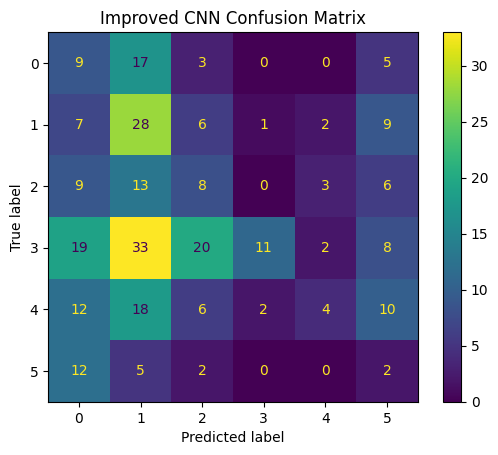

In [128]:
test_loss_small, test_acc_small = cnn_small.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_small = cnn_small.predict(X_test_cnn)
y_pred_small = np.argmax(y_pred_probs_small, axis=1)

pm1_acc_small = within_one_accuracy(y_test_cnn, y_pred_small)

print("Improved CNN Test Loss:", test_loss_small)
print("Improved CNN Test Accuracy:", test_acc_small)
print("Improved CNN ±1 Class Accuracy:", pm1_acc_small)

print(classification_report(y_test_cnn, y_pred_small))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_small)
plt.title("Improved CNN Confusion Matrix")
plt.show()

In [129]:
### The second CNN architecture with batch normalization and global average pooling performed worse than the original CNN. 
### It collapsed into predicting mostly one class, so it was not selected as the final model.


cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "Improved CNN",
        "Strict Accuracy": test_acc_small,
        "±1 Class Accuracy": pm1_acc_small,
        "Test Loss": test_loss_small
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.438356,0.705479,1.482527
1,Improved CNN,0.212329,0.476027,1.753427


In [130]:
import numpy as np

num_classes = len(np.unique(y_cnn))

cnn_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.6),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

cnn_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v2.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_16 (RandomFlip)     │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_16              │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_16 (RandomZoom)     │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_84 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_85 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,697,574 (25.55 MB)

 Trainable params: 6,697,574 (25.55 MB)

 Non-trainable params: 0 (0.00 B)

In [131]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history_v2 = cnn_v2.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=40,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.1459 - loss: 1.7972 - val_accuracy: 0.1624 - val_loss: 1.7917 - learning_rate: 3.0000e-04
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - accuracy: 0.1663 - loss: 1.7882 - val_accuracy: 0.2607 - val_loss: 1.7588 - learning_rate: 3.0000e-04
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 189ms/step - accuracy: 0.2157 - loss: 1.7874 - val_accuracy: 0.2308 - val_loss: 1.7594 - learning_rate: 3.0000e-04
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.2275 - loss: 1.7774 - val_accuracy: 0.2991 - val_loss: 1.7581 - learning_rate: 3.0000e-04
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.2232 - loss: 1.7671 - val_accuracy: 0.2821 - val_loss: 1.6921 - learning_rate: 3.0000e-04
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.2479 - loss: 1.7656 - val_accuracy: 0.3034 - val_loss: 1.6977 - learning_rate: 3.0000e-04
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step
CNN v2 Test Loss: 1.5931591987609863
CNN v2 Test Accuracy: 0.3287671208381653
CNN v2 ±1 Class Accuracy: 0.5821917808219178
              precision    recall  f1-score   support

           0       0.28      0.44      0.34        34
           1       0.31      0.32      0.32        53
           2       0.24      0.15      0.19        39
           3       0.48      0.32      0.38        93
           4       0.34      0.37      0.35        52
           5       0.22      0.43      0.29        21

    accuracy                           0.33       292
   macro avg       0.31      0.34      0.31       292
weighted avg       0.35      0.33      0.33       292



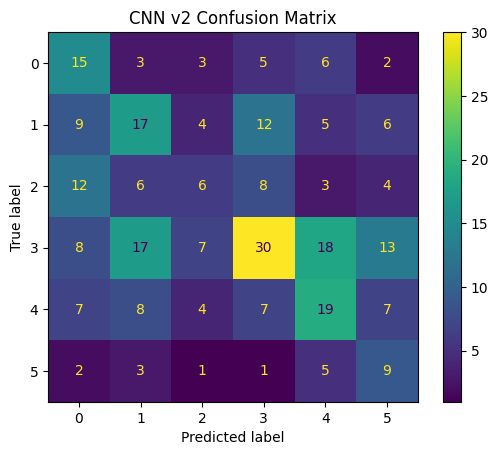

In [132]:
test_loss_v2, test_acc_v2 = cnn_v2.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_v2 = cnn_v2.predict(X_test_cnn)
y_pred_v2 = np.argmax(y_pred_probs_v2, axis=1)

pm1_acc_v2 = within_one_accuracy(y_test_cnn, y_pred_v2)

print("CNN v2 Test Loss:", test_loss_v2)
print("CNN v2 Test Accuracy:", test_acc_v2)
print("CNN v2 ±1 Class Accuracy:", pm1_acc_v2)

print(classification_report(y_test_cnn, y_pred_v2, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_v2)
plt.title("CNN v2 Confusion Matrix")
plt.show()

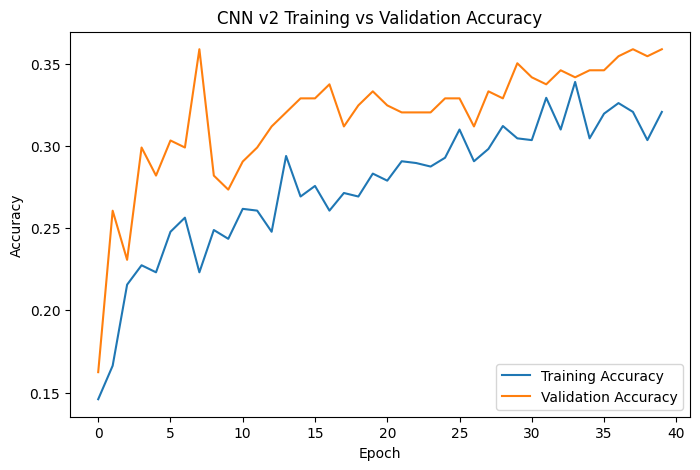

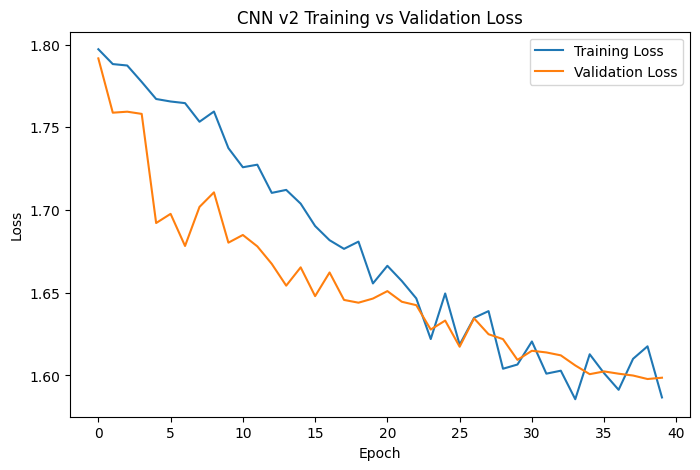

In [133]:
plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["accuracy"], label="Training Accuracy")
plt.plot(history_v2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN v2 Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_v2.history["loss"], label="Training Loss")
plt.plot(history_v2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN v2 Training vs Validation Loss")
plt.legend()
plt.show()

In [134]:
cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "CNN v2",
        "Strict Accuracy": test_acc_v2,
        "±1 Class Accuracy": pm1_acc_v2,
        "Test Loss": test_loss_v2
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.438356,0.705479,1.482527
1,CNN v2,0.328767,0.582192,1.593159


### Trying another CNN

In [135]:

num_classes = len(np.unique(y_cnn))

cnn_v3 = models.Sequential([
    layers.Input(shape=(224, 224, 4)),

    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(num_classes, activation="softmax")
])

cnn_v3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_v3.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_17 (RandomFlip)     │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_17              │ (None, 224, 224, 4)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_17 (RandomZoom)     │ (None, 224, 224, 4)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_92 (Conv2D)              │ (None, 224, 224, 32)   │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_86 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_93 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_87 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,374 (1.61 MB)

 Trainable params: 422,374 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [136]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history_v3 = cnn_v3.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 225ms/step - accuracy: 0.1438 - loss: 1.7967 - val_accuracy: 0.2179 - val_loss: 1.7899 - learning_rate: 3.0000e-04
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.1792 - loss: 1.7890 - val_accuracy: 0.1923 - val_loss: 1.7797 - learning_rate: 3.0000e-04
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 206ms/step - accuracy: 0.1856 - loss: 1.7844 - val_accuracy: 0.2479 - val_loss: 1.7672 - learning_rate: 3.0000e-04
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 204ms/step - accuracy: 0.1674 - loss: 1.7824 - val_accuracy: 0.2051 - val_loss: 1.7710 - learning_rate: 3.0000e-04
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.1878 - loss: 1.7793 - val_accuracy: 0.2393 - val_loss: 1.7651 - learning_rate: 3.0000e-04
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - accuracy: 0.1921 - loss: 1.7807 - val_accuracy: 0.1880 - val_loss: 1.7688 - learning_rate: 3.0000e-04
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 12s 203ms/step - acc

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
CNN v3 Test Loss: 1.6561880111694336
CNN v3 Test Accuracy: 0.2876712381839752
CNN v3 ±1 Class Accuracy: 0.5958904109589042
              precision    recall  f1-score   support

           0       0.25      0.65      0.36        34
           1       0.37      0.13      0.19        53
           2       0.26      0.46      0.33        39
           3       0.41      0.15      0.22        93
           4       0.32      0.40      0.36        52
           5       0.14      0.10      0.11        21

    accuracy                           0.29       292
   macro avg       0.29      0.32      0.26       292
weighted avg       0.33      0.29      0.26       292



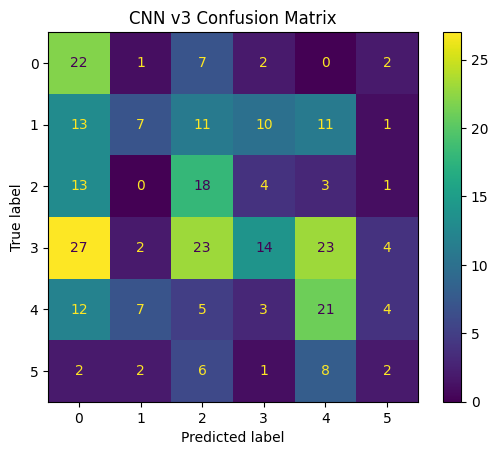

In [137]:
test_loss_v3, test_acc_v3 = cnn_v3.evaluate(X_test_cnn, y_test_cnn, verbose=0)

y_pred_probs_v3 = cnn_v3.predict(X_test_cnn)
y_pred_v3 = np.argmax(y_pred_probs_v3, axis=1)

pm1_acc_v3 = within_one_accuracy(y_test_cnn, y_pred_v3)

print("CNN v3 Test Loss:", test_loss_v3)
print("CNN v3 Test Accuracy:", test_acc_v3)
print("CNN v3 ±1 Class Accuracy:", pm1_acc_v3)

print(classification_report(y_test_cnn, y_pred_v3, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test_cnn, y_pred_v3)
plt.title("CNN v3 Confusion Matrix")
plt.show()

In [138]:
cnn_comparison = pd.DataFrame([
    {
        "Model": "Original CNN",
        "Strict Accuracy": test_acc,
        "±1 Class Accuracy": cnn_pm1_acc,
        "Test Loss": test_loss
    },
    {
        "Model": "CNN v2",
        "Strict Accuracy": test_acc_v2,
        "±1 Class Accuracy": pm1_acc_v2,
        "Test Loss": test_loss_v2
    },
    {
        "Model": "CNN v3",
        "Strict Accuracy": test_acc_v3,
        "±1 Class Accuracy": pm1_acc_v3,
        "Test Loss": test_loss_v3
    }
])

cnn_comparison

,Model,Strict Accuracy,±1 Class Accuracy,Test Loss
0,Original CNN,0.438356,0.705479,1.482527
1,CNN v2,0.328767,0.582192,1.593159
2,CNN v3,0.287671,0.595890,1.656188


## CNN Model Comparison

Three CNN architectures were tested. The original CNN performed the best overall, achieving the highest strict accuracy, highest ±1 class accuracy, and lowest test loss. CNN v2 and CNN v3 were intended to reduce overfitting through augmentation, dropout, and architectural changes, but both performed worse on the test set.

Because the original CNN had the best overall performance, it was selected as the final neural network model.